In [ ]:
Support Vector machine
Dataset Selection:
Data set Description described in another document “Drug Response Classification”
Task 1: Exploratory Data Analysis (EDA)
1.	Load the dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 
df = pd.read_csv("/Users/SS/Downloads/Pharma_Industry.csv")
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [ ]:
Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.


In [2]:
print(df.head())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


In [ ]:
Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.


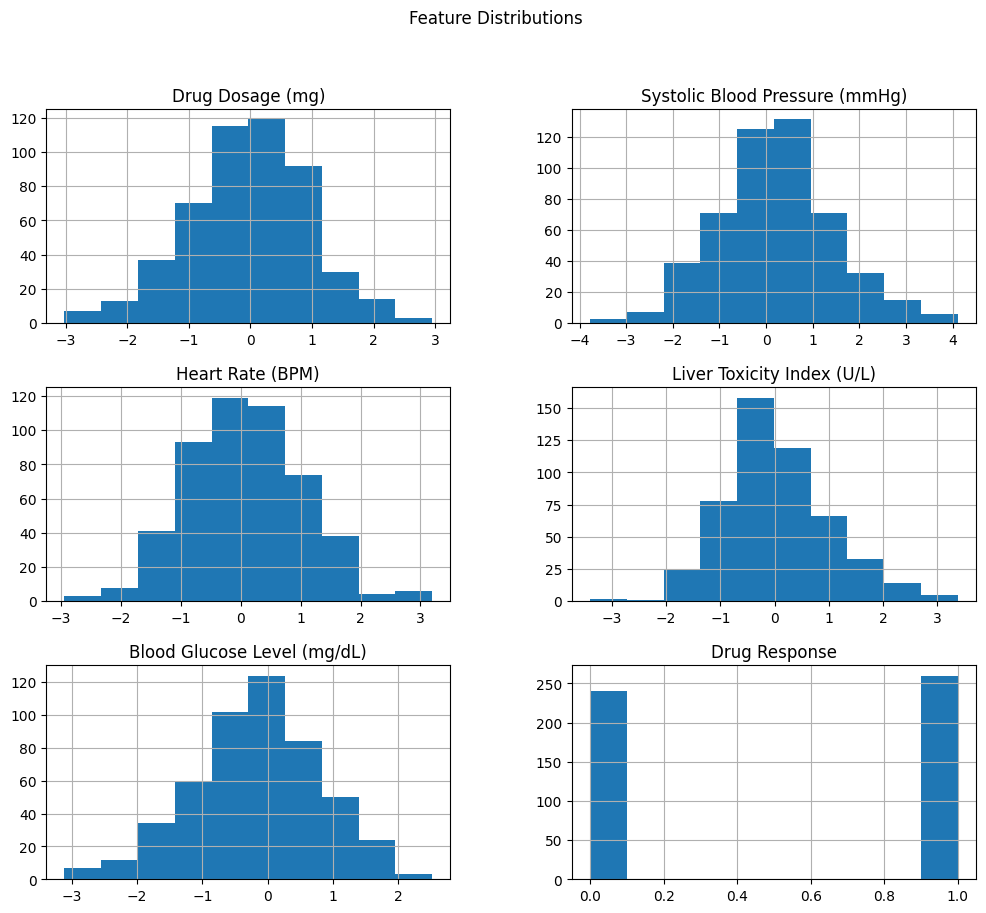

In [4]:
# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

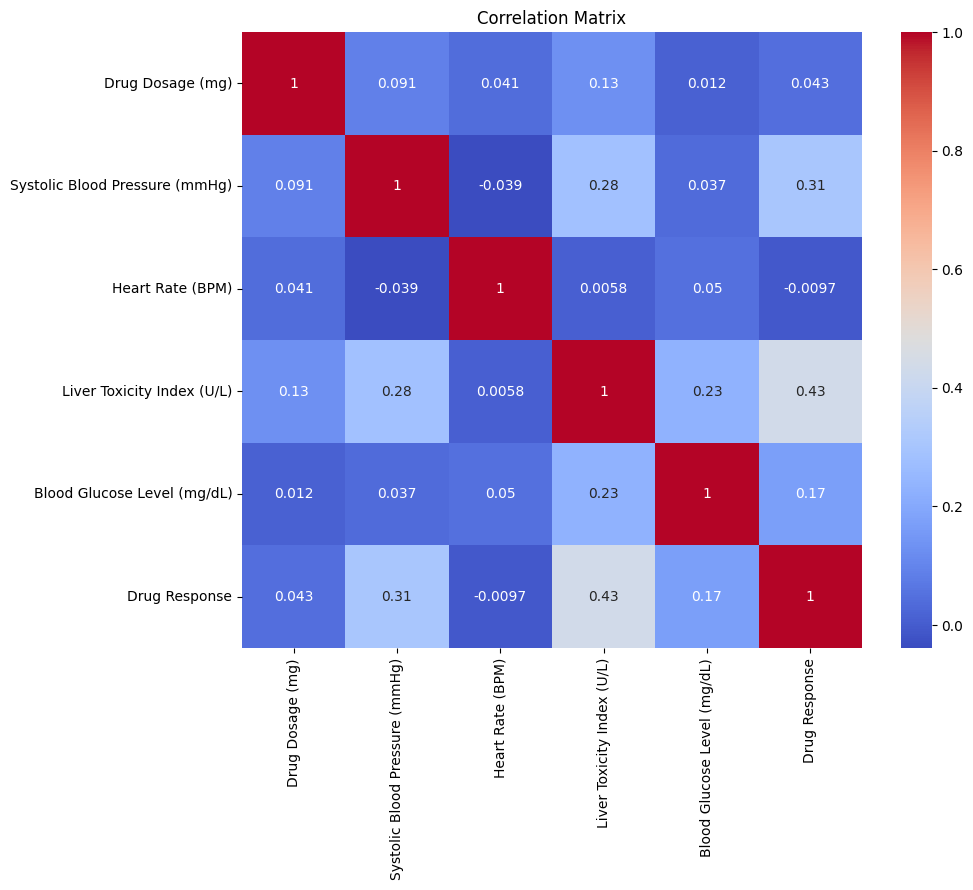

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


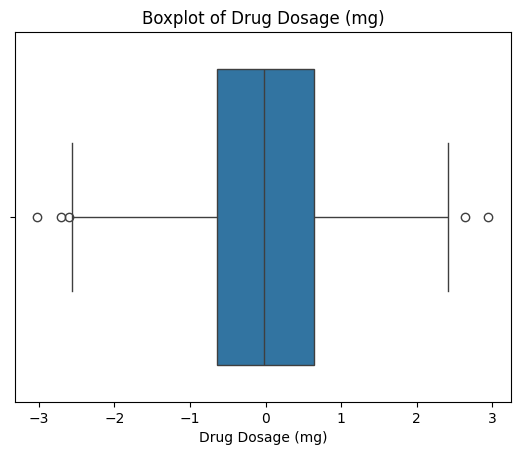

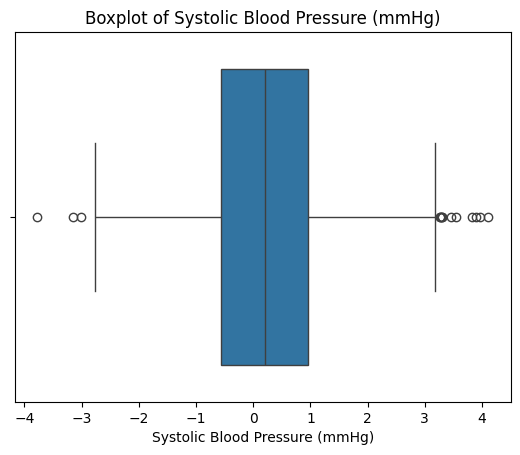

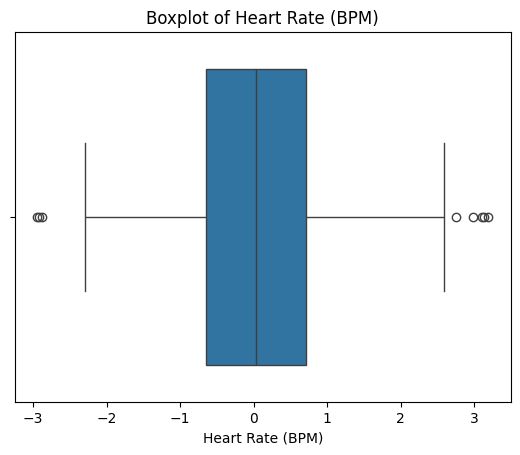

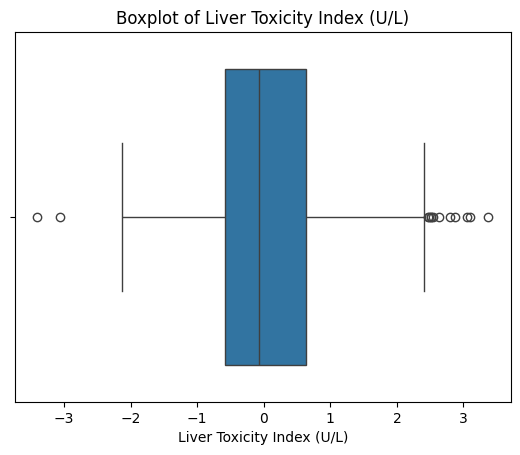

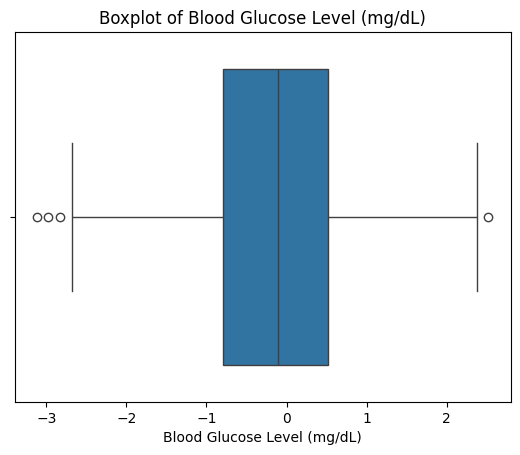

In [6]:
# Boxplots
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


In [14]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.


Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



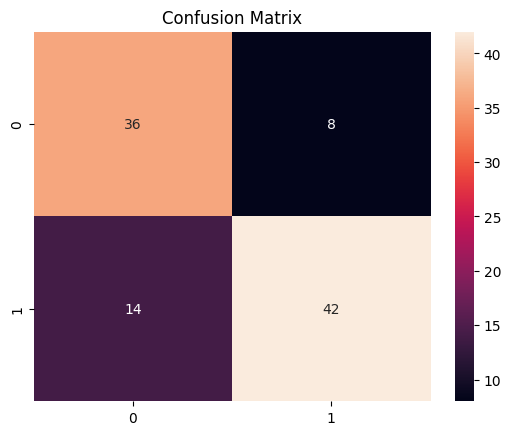

In [12]:
# 5. SVM Model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# 6. Kernel 

In [ ]:
Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance

Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.

In [13]:

for kernel in ['linear', 'rbf', 'poly']:
    m = SVC(kernel=kernel)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"{kernel} Accuracy:", accuracy_score(y_test, pred))

linear Accuracy: 0.78
rbf Accuracy: 0.84
poly Accuracy: 0.71


In [ ]:
#Business Context
Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However, some drugs do not work for all patients due to individual differences in biology, metabolism, and pre-existing conditions.
Traditional clinical trials take years to conclude, with high costs and risks.
Machine learning models can help predict drug response early, saving time and resources.
Personalized medicine ensures that patients receive the right drug at the right dose.
-------------------------------------------------------------------------------------------------------------------------------
Drug Response Classification (0 = No response, 1 = Positive response)
Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is effective or not based on biological responses.
Interpretation of Classification Labels:
1.	0 = No Response
o	The drug did not have a significant effect on the patient.
o	The patient’s condition remained unchanged after taking the drug.
o	The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.
o	Possible reasons:
	The drug is not suitable for the patient.
	The dosage is ineffective.
	The patient's metabolism is resistant to the drug.
2.	1 = Positive Response
o	The drug had a beneficial effect on the patient.
o	The patient’s condition improved after taking the drug.
o	Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.
o	Possible reasons:
	The drug is effective for this patient.
	The dosage is appropriate.
	The patient’s metabolism responds well to the drug.



Why is This Classification Important?
•	Pharmaceutical Industry: Used to test new drugs and evaluate their effectiveness before FDA approval.
•	Personalized Medicine: Helps doctors prescribe drugs based on individual patient responses.
•	Machine Learning in Healthcare: Enables predictive models to forecast patient responses based on medical data.
 



--- Logistic Regression ---
Accuracy: 0.79
Confusion Matrix:
 [[34 10]
 [11 45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.76        44
           1       0.82      0.80      0.81        56

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100


--- Random Forest ---
Accuracy: 0.81
Confusion Matrix:
 [[35  9]
 [10 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79        44
           1       0.84      0.82      0.83        56

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



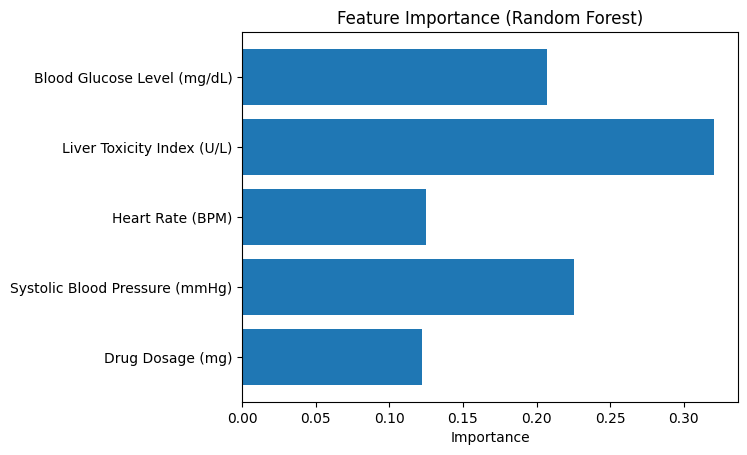


Prediction for new patient (0=No response, 1=Positive): 1


C:\Users\SS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Model 1: Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

import matplotlib.pyplot as plt

feature_importance = rf_model.feature_importances_
features = X.columns

plt.barh(features, feature_importance)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

new_patient = [[50, 120, 80, 30, 100]]  # Example values
new_patient_scaled = scaler.transform(new_patient)

prediction = lr_model.predict(new_patient_scaled)
print("\nPrediction for new patient (0=No response, 1=Positive):", prediction[0])